In [78]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebook dir
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
print('notebook_dir', notebook_dir)

# config auto reload
%load_ext autoreload
%autoreload 2

notebook_dir /home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:

SYS = 'quadrotor_2D_attitude'
controller = 'mpc_acados'
controller = 'linear_mpc_acados'
controller = 'ilqr'
controller = 'lqr'
controller = 'pid'
controller = 'gpmpc_acados_TP'

tag = '_proc_ns=5'
# tag = '_ob_ns=3'
# tag = '_dw_h=2dot5'
# tag = '_tr'
noise_type = 'downwash'

prior = f'_100_200_downwash_quadrotor_2D_attitude'
data_folder_dir = f'../{controller}/results/{prior}'
if controller in ['gpmpc_acados_TP']:
    prior = f'_100_200{tag}_{noise_type}_quadrotor_2D_attitude'
    # prior = f'_100_200{tag}_proc_noise_quadrotor_2D_attitude'
    data_folder_dir = f'../{controller}/results/{prior}'
else:
    prior = f'results_{noise_type}_{SYS}'
    data_folder_dir = f'../{controller}/{prior}'


# controller = 'ilqr'
max_seed = 10
metric_name = 'metrics.txt'
s = 2 # times std

# get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plot_color = {'ilqr': 'slateblue', 
              'lqr': 'blueviolet',
              'gpmpc_acados_TP': colors[0], 
              'mpc_acados':colors[-1], 
              'linear_mpc_acados':"green",
              'fmpc': "darkblue",
              'pid': 'tab:gray',
              } 

In [80]:


# find the folder in the dir
seed_data_folder = os.listdir(os.path.join(notebook_dir, data_folder_dir))
print('seed_data_folder', seed_data_folder)
seed_data_folder = [f for f in seed_data_folder if os.path.isdir(os.path.join(data_folder_dir, f))]
seed_data_folder = sorted(seed_data_folder, key=lambda x: int(x.split('_')[1]))
# print('seed_data_folder', seed_data_folder)
print('max seed', max_seed)
seed_data_folder = [seed_data_folder[i]+'/temp' for i in range(max_seed)]
# seed_data_folder = seed_data_folder[:9]
print('seed_data_folder', seed_data_folder)
seed_data_folder = [os.path.join(data_folder_dir, f) for f in seed_data_folder]
print('seed_data_folder', seed_data_folder)

seed_data_folder ['seed_8', 'seed_5', 'seed_1', 'seed_4', 'seed_6', 'seed_10', 'seed_3', 'seed_2', 'seed_7', 'seed_9']
max seed 10
seed_data_folder ['seed_1/temp', 'seed_2/temp', 'seed_3/temp', 'seed_4/temp', 'seed_5/temp', 'seed_6/temp', 'seed_7/temp', 'seed_8/temp', 'seed_9/temp', 'seed_10/temp']
seed_data_folder ['../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_2/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_3/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_4/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_5/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_6/temp', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_7/temp', '../gpmpc_acados_TP/results/_100_200_p

In [81]:

results = {}

for seed in range(0, max_seed):
    results[repr(seed)] = {}
    rmse_list = []
    early_stop_list = []
    noise_factor_list = []
    traj_data_list = []
    traj_steps_list = []
    # fild runs
    load_seed_dir = seed_data_folder[seed]
    runs_data_folder = os.listdir(os.path.join(notebook_dir, load_seed_dir))
    runs_data_folder = [os.path.join(load_seed_dir, f) for f in runs_data_folder]
    # sort the runs
    runs_data_folder = sorted(runs_data_folder)
    print('runs_data_folder', runs_data_folder)
    for runs in runs_data_folder:
        # load the metric file in the folder
        metric_file = os.path.join(runs, metric_name)
        # print('metric_file', metric_file)
        data = pd.read_csv(metric_file, delimiter=':')
        # convert to numpy
        data = data.to_numpy()
        # print(data)
        # convert to dictionary
        data = {data[i][0]: data[i][1] for i in range(len(data))}

        # noise_factor = eval(data['noise_factor'])
        noise_factor = eval(data['dw_height'])
        rmse = eval(data['rmse'])
        early_stop = eval(data['early_stop'])
        rmse_list.append(rmse)
        early_stop_list.append(early_stop)
        noise_factor_list.append(noise_factor)

        # load the traj
        traj_file = os.path.join(runs, f'{controller}_data_quadrotor_traj_tracking.pkl')
        traj_data = pd.read_pickle(traj_file)
        traj_data = traj_data['trajs_data']['obs'][0]
        traj_steps = len(traj_data)
        traj_data_list.append(traj_data)
        traj_steps = len(traj_data)
        traj_steps_list.append(traj_steps)
    
    results[repr(seed)]['rmse'] = rmse_list
    results[repr(seed)]['early_stop'] = early_stop_list
    results[repr(seed)]['dw_height'] = noise_factor_list
    # results[repr(seed)]['traj_data'] = traj_data_list
    results[repr(seed)]['traj_steps'] = traj_steps_list

max_noise_factor = max([max(results[repr(seed)]['dw_height']) for seed in range(max_seed)])


runs_data_folder ['../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-05-02_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-10-00_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-14-58_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-19-57_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-24-57_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-29-56_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-34-56_556dbad', '../gpmpc_acados_TP/results/_100_200_proc_ns=5_downwash_quadrotor_2D_attitude/seed_1/temp/seed1_Mar-05-01-39-54_556dbad', '../gp

In [100]:
results[repr(2)]['rmse']

[0.14504385362056366,
 0.04463808146679178,
 0.058995400858538855,
 0.050062537868347474,
 0.04465790854685819,
 0.04132712594686229,
 0.0390742584271341,
 0.037839820334271065,
 0.03681971729342306,
 0.03609190776759355,
 0.035533996716196184,
 0.0352818074920886,
 0.03474133905744397]

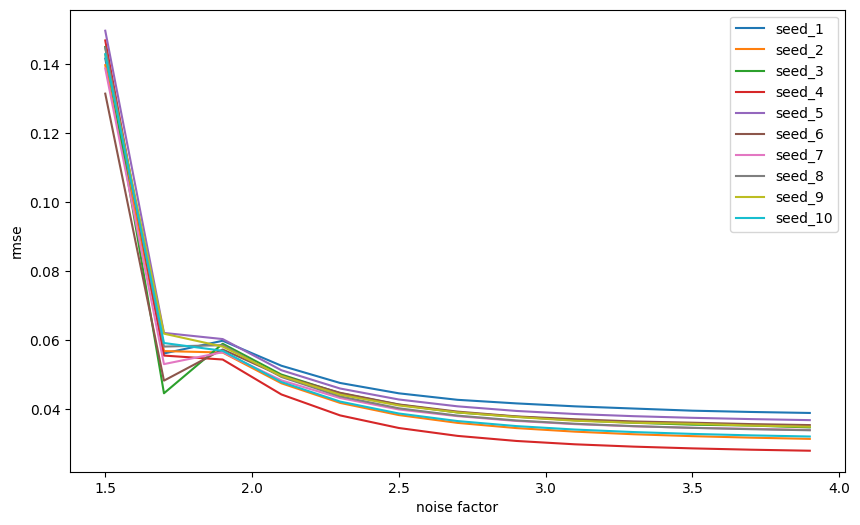

In [83]:
# plot the results
# x axis noise factor
# y axis rmse
fig, ax = plt.subplots(figsize=(10, 6))
for seed in range(max_seed):
    ax.plot(results[repr(seed)]['dw_height'], results[repr(seed)]['rmse'], label=f'seed_{seed+1}')
ax.set_xlabel('noise factor')
ax.set_ylabel('rmse')
ax.legend()

In [84]:
# early stop
# results[repr(seed)]['early_stop']
# merge all the early stop
num_noise_factor = len(results[repr(seed)]['dw_height'])
print('num_noise_factor', num_noise_factor)
early_stop_results = [False for _ in range(num_noise_factor)]
print('early_stop_results', early_stop_results)
print('len(early_stop_results)', len(early_stop_results))
for seed in range(max_seed):
    for i in range(len(results[repr(seed)]['dw_height'])):
        early_stop_results[i] = early_stop_results[i] or results[repr(seed)]['early_stop'][i]
print('early_stop_results', early_stop_results)
# find the first early stop
if True in early_stop_results:
    first_early_stop = early_stop_results.index(True)
    early_stop_noise_factor = results[repr(seed)]['dw_height'][first_early_stop]
else:
    print('no early stop')
    first_early_stop = None
    early_stop_noise_factor = None
print('first_early_stop', first_early_stop)
print('early_stop_noise_factor', early_stop_noise_factor)

num_noise_factor 13
early_stop_results [False, False, False, False, False, False, False, False, False, False, False, False, False]
len(early_stop_results) 13
early_stop_results [[0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]]
no early stop
first_early_stop None
early_stop_noise_factor None


#### convert dw position to force applied at the center

In [95]:
from safe_control_gym.envs.disturbances import Downwash
dw_model = Downwash()
def compute_center_force(dw_height):
    '''
    compute the downwash force at the center of the reference trajectory

    Args:
    - dw_height [m]: float, the height of the disturbance source quadrotor
    '''
    traj_center = np.array([0.0, 0.0, 1.0])
    dw_quad_pos = np.array([0.0, 0.0, dw_height])
    delta_pos = traj_center - dw_quad_pos
    dw_center_force = dw_model.get_dw_force_mag(delta_pos)
    return dw_center_force

In [86]:
# rmse

#### preprocesing

In [87]:
rmse = np.array([results[repr(seed)]['rmse'] for seed in range(max_seed)])
early_stop = np.array([results[repr(seed)]['early_stop'] for seed in range(max_seed)])
dw_height = np.array([results[repr(seed)]['dw_height'] for seed in range(max_seed)])
dw_height = dw_height[0]
dw_center_force = np.array([compute_center_force(dw_height[i]) for i in range(len(dw_height))])

# compute the mean and std
rmse_mean = np.mean(rmse, axis=0)
rmse_std = np.std(rmse, axis=0)
rmse_max = np.max(rmse, axis=0)

# compute rmse degradation
rmse_degradation = rmse / rmse[:, -1][:, None] * 100
rmse_degradation_mean = np.mean(rmse_degradation, axis=0)
rmse_degradation_std = np.std(rmse_degradation, axis=0)

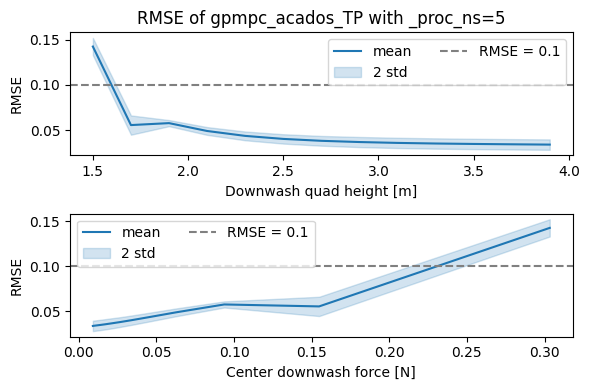

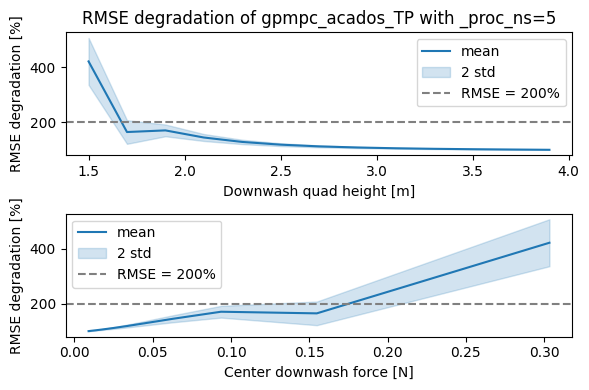

In [94]:

fig, ax = plt.subplots(2, 1, figsize=(6, 4))
ax[0].plot(dw_height, rmse_mean,
        label='mean', color=plot_color[controller])
ax[0].fill_between(dw_height, rmse_mean- s*rmse_std, rmse_mean+ s*rmse_std, 
                alpha=0.2, label=f'{s} std', color=plot_color[controller])

# [0]plot y line at 0.1
ax[0].axhline(y=0.1, color='gray', linestyle='--', label='RMSE = 0.1')
ax[0].legend(ncol=2)
ax[0].set_xlabel('Downwash quad height [m]')
ax[0].set_ylabel('RMSE')
ax[0].set_title(f'RMSE of {controller} with {tag}')

# save the plot
# plot_file_name = f'{notebook_dir}/../data/{tag}_rmse_{controller}.png'
# plt.savefig(plot_file_name)

# plot the rmse wrt to the center force
ax[1].plot(dw_center_force, rmse_mean,
        label='mean', color=plot_color[controller])
ax[1].fill_between(dw_center_force, rmse_mean- s*rmse_std, rmse_mean+ s*rmse_std, 
                alpha=0.2, label=f'{s} std', color=plot_color[controller])
ax[1].axhline(y=0.1, color='gray', linestyle='--', label='RMSE = 0.1')
ax[1].legend(ncol=2)
ax[1].set_xlabel('Center downwash force [N]')
ax[1].set_ylabel('RMSE')
# ax[1].set_title(f'RMSE of {controller} with {tag}')
fig.tight_layout()

# plot the rmse degradation
fig, ax = plt.subplots(2, 1, figsize=(6, 4))
ax[0].plot(dw_height, rmse_degradation_mean,
        label='mean', color=plot_color[controller])
ax[0].fill_between(dw_height, rmse_degradation_mean- s*rmse_degradation_std, rmse_degradation_mean+ s*rmse_degradation_std, 
                alpha=0.2, label=f'{s} std', color=plot_color[controller])
ax[0].axhline(y=200, color='gray', linestyle='--', label='RMSE = 200%')
ax[0].legend()
ax[0].set_title(f'RMSE degradation of {controller} with {tag}')
ax[0].set_xlabel('Downwash quad height [m]')
ax[0].set_ylabel('RMSE degradation [%]')

# plot the rmse degradation wrt to the center force
ax[1].plot(dw_center_force, rmse_degradation_mean,
        label='mean', color=plot_color[controller])
ax[1].fill_between(dw_center_force, rmse_degradation_mean- s*rmse_degradation_std, rmse_degradation_mean+ s*rmse_degradation_std, 
                alpha=0.2, label=f'{s} std', color=plot_color[controller])
ax[1].axhline(y=200, color='gray', linestyle='--', label='RMSE = 200%')
ax[1].legend()
ax[1].set_xlabel('Center downwash force [N]')
ax[1].set_ylabel('RMSE degradation [%]')
fig.tight_layout()


In [98]:
# results[repr(1)]['traj_steps']
# results.keys
print('rmse.shape', rmse.shape)
saved_results = {
    'rmse': rmse,
    'rmse_mean': rmse_mean,
    'rmse_std': rmse_std,
    'rmse_max': rmse_max,
    'rmse_degradation': rmse_degradation,
    'rmse_degradation_mean': rmse_degradation_mean,
    'rmse_degradation_std': rmse_degradation_std,
    'dw_height': dw_height,
    'dw_center_force': dw_center_force,
    'early_stop_results': early_stop_results,
    'early_stop_dw_height': early_stop_noise_factor,
}
if controller in ['gpmpc_acados_TP']:
    results_file_name = f'{notebook_dir}/../data/{controller}{tag}_{noise_type}_results.npy'
else:
    results_file_name = f'{notebook_dir}/../data/{controller}_{noise_type}_results.npy'
np.save(results_file_name, results)
print(f'saved {notebook_dir}/{results_file_name}')

rmse.shape (10, 13)
saved /home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting//home/mingxuan/Repositories/scg_tsung/benchmarking_sim/quadrotor/plotting/../data/gpmpc_acados_TP_proc_ns=5_downwash_results.npy
